In [1]:
import os

import sys
sys.path.append('/home/joonhi/pytool/')
#sys.path.append('/home/yujin/MITgcm/utils/python/MITgcmutils/')

import numpy as np
from netCDF4 import Dataset
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from MITgcmutils import rdmds, densjmd95
from asmlpy import interp_nonreg_xyz, inpaint_nans, interp_nonreg_xy
RC=rdmds('/data6/LLC270_darwin/run_div/RC')


## read and interpolate cesm data to CORE2 grid

In [3]:
ds = xr.open_dataset("/home/joonhi/research/cesm_data/uas_day_GFDL-CM4_abrupt-4xCO2_r1i1p1f1_gr1_00010101-00201231.nc")
sst_data = ds["uas"].values
sst_data=sst_data[0:365]

In [ ]:
ds = xr.open_dataset("/home/joonhi/research/cesm_data/uas_day_GFDL-CM4_abrupt-4xCO2_r1i1p1f1_gr1_01410101-01501231.nc")
sst_data = ds["uas"].values
sst_data=sst_data[0:365]

In [39]:
import os
import subprocess
import numpy as np


# ============================================================
# 1. 기본 경로 설정
# ============================================================

cdo = "/usr/local/cdo/1.9.3/bin/cdo"
var = "pr"

infile = (
    "/home/joonhi/research/cesm_data/"
    "pr_day_GFDL-CM4_abrupt-4xCO2_r1i1p1f1_gr1_"
    "01410101-01501231.nc"
)

gridfile = (
    "/home/joonhi/research/cesm_data/"
    "CORE2_atemp_192x94_grid.txt"
)

outfile = (
    "/home/joonhi/research/cesm_data/"
    "pr_daily_last_CORE2grid.nc"
)


# ============================================================
# 2. CORE2 atemp 격자 정보
# ============================================================

atemp_lon0 = 0.0
atemp_lon_inc = 1.875
atemp_nlon = 192

atemp_lat0 = -88.5420
atemp_nlat = 94

atemp_lat_inc = np.array([
    1.8888,
    1.9000,
    1.9024,
    1.9034,
    1.9039,
    1.9042,
    1.9042,
    1.9044,
    1.9045,
    1.9045,
    1.9046,
    1.9046,
    1.9046,
    1.9046,
    1.9047,
    1.9046,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9048,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9047,
    1.9046,
    1.9047,
    1.9046,
    1.9046,
    1.9046,
    1.9046,
    1.9045,
    1.9045,
    1.9044,
    1.9042,
    1.9042,
    1.9039,
    1.9034,
    1.9024,
    1.9000,
    1.8888,
    1.8888
], dtype=np.float64)


# ============================================================
# 3. latitude increment로 실제 latitude 좌표 생성
# ============================================================

# 위도 중심점이 94개이면 중심점 사이의 간격은 93개가 필요함
if len(atemp_lat_inc) < atemp_nlat - 1:
    raise ValueError(
        f"위도 간격 개수가 부족합니다: "
        f"{len(atemp_lat_inc)}개, 최소 {atemp_nlat - 1}개 필요"
    )

atemp_lat = np.empty(atemp_nlat, dtype=np.float64)

atemp_lat[0] = atemp_lat0
atemp_lat[1:] = (
    atemp_lat0
    + np.cumsum(atemp_lat_inc[:atemp_nlat - 1])
)

print("Latitude grid")
print("  number :", len(atemp_lat))
print("  first  :", atemp_lat[0])
print("  last   :", atemp_lat[-1])
print("  monotonic:", np.all(np.diff(atemp_lat) > 0))

if not np.all(np.diff(atemp_lat) > 0):
    raise ValueError("위도 좌표가 증가하는 순서가 아닙니다.")

if np.any(atemp_lat < -90.0) or np.any(atemp_lat > 90.0):
    raise ValueError("생성된 위도가 -90~90도 범위를 벗어났습니다.")


# ============================================================
# 4. CDO grid-description 파일 생성
# ============================================================

os.makedirs(os.path.dirname(gridfile), exist_ok=True)

with open(gridfile, "w") as f:
    f.write("gridtype = gaussian\n")
    f.write(f"gridsize = {atemp_nlon * atemp_nlat}\n")
    f.write(f"xsize = {atemp_nlon}\n")
    f.write(f"ysize = {atemp_nlat}\n")

    f.write('xname = "lon"\n')
    f.write('xlongname = "longitude"\n')
    f.write('xunits = "degrees_east"\n')

    f.write('yname = "lat"\n')
    f.write('ylongname = "latitude"\n')
    f.write('yunits = "degrees_north"\n')

    f.write(f"xfirst = {atemp_lon0:.8f}\n")
    f.write(f"xinc = {atemp_lon_inc:.8f}\n")

    # 긴 yvals를 여러 줄로 나누어 기록
    f.write("yvals = ")

    values_per_line = 8

    for i, value in enumerate(atemp_lat):
        if i > 0 and i % values_per_line == 0:
            f.write("\n        ")

        f.write(f"{value:.8f} ")

    f.write("\n")


print(f"\nGrid file created:\n{gridfile}")


# ============================================================
# 5. 생성된 grid 파일 내용 확인
# ============================================================

with open(gridfile, "r") as f:
    print("\n----- GRID FILE -----")
    print(f.read())
    print("---------------------")


# ============================================================
# 6. CDO를 이용하여 GFDL-CM4 tas를 CORE2 격자로 변환
# ============================================================

command = [
    cdo,
    "-O",
    "-f", "nc4",
    f"remapbil,{gridfile}",
    f"-selname,{var}",
    infile,
    outfile
]

print("\nRunning CDO command:")
print(" ".join(command))

subprocess.run(command, check=True)

print(f"\nRemapped file created:\n{outfile}")


# ============================================================
# 7. 결과 격자 확인
# ============================================================

print("\nOutput grid description:")

subprocess.run(
    [cdo, "griddes", outfile],
    check=True
)

Latitude grid
  number : 94
  first  : -88.542
  last   : 88.54199999999992
  monotonic: True

Grid file created:
/home/joonhi/research/cesm_data/CORE2_atemp_192x94_grid.txt

----- GRID FILE -----
gridtype = gaussian
gridsize = 18048
xsize = 192
ysize = 94
xname = "lon"
xlongname = "longitude"
xunits = "degrees_east"
yname = "lat"
ylongname = "latitude"
yunits = "degrees_north"
xfirst = 0.00000000
xinc = 1.87500000
yvals = -88.54200000 -86.65320000 -84.75320000 -82.85080000 -80.94740000 -79.04350000 -77.13930000 -75.23510000 
        -73.33070000 -71.42620000 -69.52170000 -67.61710000 -65.71250000 -63.80790000 -61.90330000 -59.99860000 
        -58.09400000 -56.18930000 -54.28460000 -52.37990000 -50.47520000 -48.57050000 -46.66580000 -44.76110000 
        -42.85640000 -40.95170000 -39.04700000 -37.14220000 -35.23750000 -33.33280000 -31.42810000 -29.52340000 
        -27.61860000 -25.71390000 -23.80920000 -21.90440000 -19.99970000 -18.09500000 -16.19020000 -14.28550000 
        -12.3808

cdo remapbil: Started child process "selname,pr /home/joonhi/research/cesm_data/pr_day_GFDL-CM4_abrupt-4xCO2_r1i1p1f1_gr1_01410101-01501231.nc (pipe1.1)".
cdo remapbil: SCRIP bilinear weights from lonlat (288x180) to gaussian (192x94) grid



Remapped file created:
/home/joonhi/research/cesm_data/pr_daily_last_CORE2grid.nc

Output grid description:
#
# gridID 1
#
gridtype  = gaussian
gridsize  = 18048
xsize     = 192
ysize     = 94
xname     = lon
xlongname = "longitude"
xunits    = "degrees_east"
yname     = lat
ylongname = "latitude"
yunits    = "degrees_north"
np        = 47
xfirst    = 0
xinc      = 1.875
yvals     = -88.542 -86.6532 -84.7532 -82.8508 -80.9474 -79.0435 -77.1393 -75.2351 
            -73.3307 -71.4262 -69.5217 -67.6171 -65.7125 -63.8079 -61.9033 -59.9986 
            -58.094 -56.1893 -54.2846 -52.3799 -50.4752 -48.5705 -46.6658 -44.7611 
            -42.8564 -40.9517 -39.047 -37.1422 -35.2375 -33.3328 -31.4281 -29.5234 
            -27.6186 -25.7139 -23.8092 -21.9044 -19.9997 -18.095 -16.1902 -14.2855 
            -12.3808 -10.476 -8.5713 -6.6666 -4.7618 -2.8571 -0.9524 0.9524 2.8571 
            4.7618 6.6666 8.5713 10.476 12.3808 14.2855 16.1902 18.095 19.9997 21.9044 
            23.8092 25.7139 27.6

cdo(2) selname: Processed 189216000 values from 1 variable over 3650 timesteps [6.23s]
cdo remapbil: Processed 189216000 values from 1 variable over 3650 timesteps [6.23s 569MB]
cdo griddes: Processed 1 variable [0.00s 569MB]


CompletedProcess(args=['/usr/local/cdo/1.9.3/bin/cdo', 'griddes', '/home/joonhi/research/cesm_data/pr_daily_last_CORE2grid.nc'], returncode=0)

## test your data

In [30]:
ds = xr.open_dataset("/home/joonhi/research/cesm_data/uas_daily_last_CORE2grid.nc")
sst_data = ds["uas"].values
sst_data=sst_data[0:365]

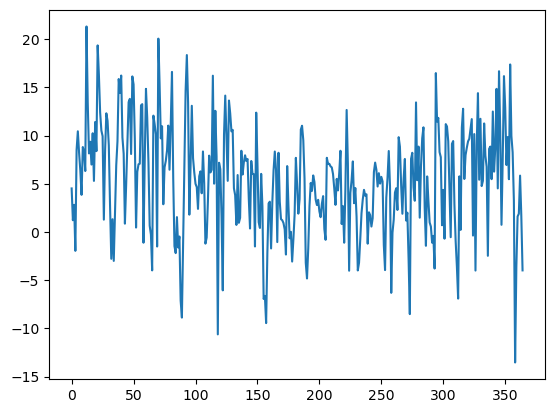

In [31]:
plt.plot(sst_data[:,70,100])

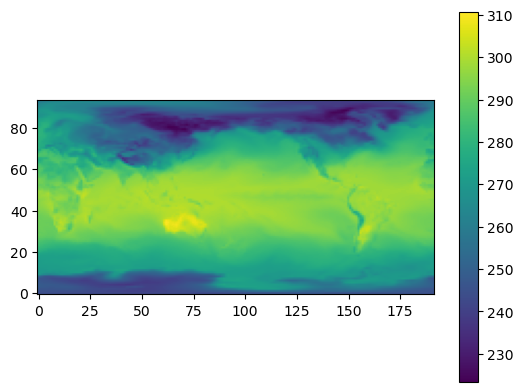

In [25]:
plt.imshow(sst_data[0],origin='lower')
plt.colorbar()